# chess opening analysis

going through my pgn files for top 10 players and tagging each game with its opening (ECO code)
so I can compare what everyone actually plays.

paths are relative now so this runs on any machine, don't need to be on windows anymore

In [1]:
%pip install chess pandas numpy matplotlib

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import chess.pgn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import re
from collections import defaultdict

## step 1 - pgn to csv

same thing as before, just looping over all the players instead of copy pasting the cell 10 times

In [3]:
data_dir = Path("../data/chess_games")

players = ["Carlsen", "Caruana", "Erigaisi", "Firouzja", "Giri",
           "Gukesh", "Keymer", "Nakamura", "Praggnanandhaa", "Wei"]

In [4]:
def pgn_to_df(pgn_path):
    games = []
    pgn = open(pgn_path, encoding="utf-8", errors="replace")

    while True:
        game = chess.pgn.read_game(pgn)
        if game is None:
            break

        headers = game.headers
        games.append({
            "Event": headers.get("Event"),
            "Site": headers.get("Site"),
            "Date": headers.get("Date"),
            "White": headers.get("White"),
            "Black": headers.get("Black"),
            "Result": headers.get("Result"),
            "WhiteElo": headers.get("WhiteElo"),
            "BlackElo": headers.get("BlackElo"),
            "Opening": headers.get("Opening"),
            "Moves": game.board().variation_san(game.mainline_moves())
        })

    return pd.DataFrame(games)

In [5]:
# convert everyone. this takes a couple minutes for carlsen/nakamura since they have way more games
for p in players:
    pgn_path = data_dir / f"{p}.pgn"
    csv_path = data_dir / f"{p}.csv"

    df = pgn_to_df(pgn_path)
    df.to_csv(csv_path, index=False)
    print(p, len(df), "games")

Carlsen 7073 games


Caruana 5699 games


Erigaisi 3763 games


Firouzja 4603 games


Giri 4303 games


Gukesh 2153 games


Keymer 2600 games


Nakamura 9204 games


Praggnanandhaa 2630 games


Wei 1913 games


In [6]:
# load them all back in
dfs = {}
for p in players:
    dfs[p] = pd.read_csv(data_dir / f"{p}.csv")

df = dfs["Carlsen"]
df.head()

,Event,Site,Date,White,Black,Result,WhiteElo,BlackElo,Opening,Moves
0,Troll Masters,Gausdal NOR,2001.01.05,"Edvardsen,R","Carlsen,Magnus",1/2-1/2,2055.0,NaN,NaN,1. d4 Nf6 2. Nf3 d5 3. e3 Bf5 4. c4 c6 5. Nc3 ...
1,Troll Masters,Gausdal NOR,2001.01.06,"Carlsen,Magnus","Brameld,A",0-1,NaN,2095.0,NaN,1. e4 Nf6 2. e5 Nd5 3. d4 d6 4. Nf3 Bg4 5. Bc4...
2,Troll Masters,Gausdal NOR,2001.01.07,"Carlsen,Magnus","Fant,G",1-0,NaN,2062.0,NaN,1. e4 e6 2. d4 d5 3. Nc3 Bb4 4. e5 Ne7 5. a3 B...
3,Troll Masters,Gausdal NOR,2001.01.08,"Tallaksen,G","Carlsen,Magnus",1/2-1/2,2258.0,NaN,NaN,1. d4 d5 2. c4 e6 3. Nc3 Nf6 4. e3 Be7 5. Nf3 ...
4,Troll Masters,Gausdal NOR,2001.01.08,"Carlsen,Magnus","Nilssen,J",0-1,NaN,2371.0,NaN,1. e4 c5 2. Nf3 Nc6 3. d4 cxd4 4. Nxd4 e5 5. N...


In [7]:
# quick sanity check, make sure nothing's obviously broken
print(df.shape)
df["White"].value_counts().head()

(7073, 10)


White
Carlsen,M           3575
Nakamura,Hi          189
Firouzja,Alireza     128
So,W                 119
Aronian,L            118
Name: count, dtype: int64

## step 2 - eco database

loading the eco json files (these have the move sequence for every named opening) so I can match my games against them

In [8]:
eco_path = Path("../data/eco")
files = list(eco_path.glob("*.json"))
print(files)
print(len(files), "files")

[PosixPath('../data/eco/ecoD.json'), PosixPath('../data/eco/ecoA.json'), PosixPath('../data/eco/ecoE.json'), PosixPath('../data/eco/ecoB.json'), PosixPath('../data/eco/ecoC.json')]
5 files


In [9]:
eco_db = {}

for file in eco_path.glob("*.json"):
    with open(file, encoding="utf-8") as f:
        data = json.load(f)
    print(file.name, "entries:", len(data))
    eco_db.update(data)

print("total entries:", len(eco_db))

ecoD.json entries: 2273
ecoA.json entries: 2723
ecoE.json entries: 1792
ecoB.json entries: 2726
ecoC.json entries: 2865
total entries: 12377


In [10]:
eco_openings = []
for entry in eco_db.values():
    eco_openings.append({
        "eco": entry["eco"],
        "name": entry["name"],
        "moves": entry["moves"]
    })

len(eco_openings)

12377

## step 3 - matching games to openings

the eco moves look like `1. e4 c5 2. Nf3 d6` and my game moves look basically the same but I need to strip the move numbers to compare them properly

In [11]:
def normalize_moves(moves_str):
    if not isinstance(moves_str, str):
        return ""
    moves_str = re.sub(r"\d+\.", "", moves_str)
    return " ".join(moves_str.split())

In [12]:
# first attempt - just loop through every eco entry and find the longest one that matches
# works fine but it's checking ~2700 entries for every single game which is slow once you're doing
# it for 40k+ games

def detect_opening_slow(game_moves, eco_openings, max_plies=10):
    game_moves = normalize_moves(game_moves)
    if not game_moves:
        return None, None

    tokens = game_moves.split()[:max_plies]
    prefix = " ".join(tokens)

    best_match = None
    best_len = 0

    for entry in eco_openings:
        eco_moves = normalize_moves(entry["moves"])
        if prefix.startswith(eco_moves) and len(eco_moves) > best_len:
            best_match = (entry["eco"], entry["name"])
            best_len = len(eco_moves)

    return best_match if best_match else (None, None)

In [13]:
sample = df.iloc[0]["Moves"]
print(sample)
detect_opening_slow(sample, eco_openings)

1. d4 Nf6 2. Nf3 d5 3. e3 Bf5 4. c4 c6 5. Nc3 e6 6. Bd3 Bxd3 7. Qxd3 Nbd7 8. b3 Bd6 9. O-O O-O 10. Bb2 Qe7 11. Rad1 Rad8 12. Rfe1 dxc4 13. bxc4 e5 14. dxe5 Nxe5 15. Nxe5 Bxe5 16. Qe2 Rxd1 17. Rxd1 Rd8 18. Rxd8+ Qxd8 19. Qd1 Qxd1+ 20. Nxd1 Bxb2 21. Nxb2 b5 22. f3 Kf8 23. Kf2 Ke7


('A46', 'Indian Defence, Knights Variation')

In [14]:
# that works but ran this on the full carlsen df once and it took forever, so bucketing
# by the first couple moves so each game only has to check openings that start the same way

eco_prefix_map = defaultdict(list)

for entry in eco_openings:
    norm = normalize_moves(entry["moves"])
    key = " ".join(norm.split()[:4])  # first 2 moves each side
    eco_prefix_map[key].append({
        "eco": entry["eco"],
        "name": entry["name"],
        "moves": norm
    })

print("buckets:", len(eco_prefix_map))

buckets: 1056


In [15]:
def detect_opening_fast(game_moves, eco_prefix_map, max_plies=10):
    game_moves = normalize_moves(game_moves)
    if not game_moves:
        return None, None

    tokens = game_moves.split()[:max_plies]
    prefix = " ".join(tokens)
    key = " ".join(tokens[:4])

    candidates = eco_prefix_map.get(key, [])

    best_match = None
    best_len = 0

    for entry in candidates:
        eco_moves = entry["moves"]
        if prefix.startswith(eco_moves) and len(eco_moves) > best_len:
            best_match = (entry["eco"], entry["name"])
            best_len = len(eco_moves)

    return best_match if best_match else (None, None)

In [16]:
# check it gives the same answer as the slow version
print(detect_opening_slow(sample, eco_openings))
print(detect_opening_fast(sample, eco_prefix_map))

('A46', 'Indian Defence, Knights Variation')
('A46', 'Indian Defence, Knights Variation')


In [17]:
detect_opening_fast("1. d4 Nf6 2. Nf3 d5 3. e3", eco_prefix_map)

('A46', 'Indian Defence, Knights Variation')

## step 4 - tag everyone's games

In [18]:
for p in players:
    df = dfs[p]
    df["Moves"] = df["Moves"].fillna("").astype(str)  # a few rows had NaN moves, blew up detect_opening_fast without this

    df[["ECO", "OpeningDetected"]] = df["Moves"].apply(
        lambda m: pd.Series(detect_opening_fast(m, eco_prefix_map))
    )

    df.to_csv(data_dir / f"{p}_with_openings.csv", index=False)
    print(p, "-", round(df["ECO"].notna().mean() * 100, 1), "% detected")

Carlsen - 84.7 % detected


Caruana - 88.4 % detected


Erigaisi - 75.5 % detected


Firouzja - 87.0 % detected


Giri - 87.8 % detected


Gukesh - 92.4 % detected


Keymer - 71.2 % detected


Nakamura - 71.7 % detected


Praggnanandhaa - 85.4 % detected


Wei - 88.3 % detected


## step 5 - who plays what

just dumping the top openings for each player, nothing fancy

In [19]:
df1 = pd.read_csv(data_dir / "Carlsen_with_openings.csv")
df1[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                                 
C84  Ruy Lopez: Closed                                   231
B90  Sicilian Defense: Najdorf Variation                 159
C65  Spanish: Berlin, 4.d3 Bc5                           108
A46  Indian Defence, Knights Variation                    84
E10  Catalan Opening                                      76
A07  Reti: KIA                                            75
B33  Sicilian Defense: Lasker-Pelikan Variation           70
D37  Queen's Gambit Declined: Three Knights Variation     62
C67  Spanish: Open Berlin, 5.Re1                          53
A05  Reti: KIA                                            51
C67  Ruy Lopez: Berlin Defense, l'Hermet Variation        51
D85  Gruenfeld: Exchange, 5.e4 Nxc3                       48
C50  Italian Game: Giuoco Pianissimo, Normal              48
B70  Sicilian Defense: Dragon Variation                   45
D30  QGD: 3.Nf3 Nf6                                       44
Name: count, dtype: int64

In [20]:
df2 = pd.read_csv(data_dir / "Caruana_with_openings.csv")
df2[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                                          
C84  Ruy Lopez: Closed                                            170
C65  Spanish: Berlin, 4.d3 Bc5                                    155
B90  Sicilian Defense: Najdorf Variation                          135
C78  Spanish: 5.O-O b5                                             87
A46  Indian Defence, Knights Variation                             73
B33  Sicilian Defense: Lasker-Pelikan Variation                    57
D31  Queen's Gambit Declined, Queen's Knight Variation             53
C67  Ruy Lopez: Berlin Defense, l'Hermet Variation                 52
A07  Reti: KIA                                                     51
E10  Catalan Opening                                               50
C42  Russian Game: Classical, 5...d5                               45
B47  Sicilian Defense: Taimanov Variation, Bastrikov Variation     44
C80  Ruy Lopez: Open                                               43
C50  Italian Game: Giuoco P

In [21]:
df3 = pd.read_csv(data_dir / "Erigaisi_with_openings.csv")
df3[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                                  
D30  QGD: 3.Nf3 Nf6                                       62
B90  Sicilian Defense: Najdorf Variation                  55
A46  Indian Defence, Knights Variation                    53
A45  Queen's Pawn Game: Chigorin Variation                49
D31  Queen's Gambit Declined, Queen's Knight Variation    37
D02  Queen's Pawn: London                                 34
A07  Reti: KIA                                            32
E10  Catalan Opening                                      30
A13  English: 1...e6 2.Nf3 Nf6                            29
A01  Nimzo-Larsen Attack: Modern Variation                29
E73  King's Indian: 5.Be2 O-O                             27
B70  Sicilian Defense: Dragon Variation                   27
C84  Ruy Lopez: Closed                                    26
C11  French: Steinitz, 5.f4 c5                            23
A13  English Opening: Agincourt Defense                   23
Name: count, dtype: int64

In [22]:
df4 = pd.read_csv(data_dir / "Firouzja_with_openings.csv")
df4[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                        
B90  Sicilian Defense: Najdorf Variation        234
C84  Ruy Lopez: Closed                          107
C65  Spanish: Berlin, 4.d3 Bc5                   87
E90  King's Indian: 5.Nf3 O-O                    71
C50  Italian Game: Giuoco Pianissimo, Normal     60
A46  Indian Defence, Knights Variation           55
B56  Sicilian Defense: Classical Variation       52
D00  Trompowsky: 2...d5 3.e3                     48
A05  Reti: KIA                                   45
A07  Reti: KIA                                   44
A45  Queen's Pawn Game: Chigorin Variation       39
E10  Catalan Opening                             38
B23  Sicilian: Closed                            37
B12  Caro-Kann: Advance, 4.Nf3 e6 5.Be2          33
E73  King's Indian: 5.Be2 O-O                    31
Name: count, dtype: int64

In [23]:
df5 = pd.read_csv(data_dir / "Giri_with_openings.csv")
df5[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                                 
B90  Sicilian Defense: Najdorf Variation                 231
A06  Queen's Pawn Game, Symmetrical, 3.c4                106
E10  Catalan Opening                                     104
C65  Spanish: Berlin, 4.d3 Bc5                            86
A07  Reti: KIA                                            77
C84  Ruy Lopez: Closed                                    73
D85  Gruenfeld: Exchange, 5.e4 Nxc3                       68
C50  Italian Game: Giuoco Pianissimo, Normal              57
     Giuoco Piano: 4.O-O Nf6                              53
D38  Queen's Gambit Declined: Ragozin Defense             51
A46  Indian Defence, Knights Variation                    50
C67  Spanish: Open Berlin, 5.Re1                          44
     Ruy Lopez: Berlin Defense, l'Hermet Variation        38
D37  Queen's Gambit Declined: Three Knights Variation     38
C42  Russian Game: Classical, 5...d5                      32
Name: count, dtype: int64

In [24]:
df6 = pd.read_csv(data_dir / "Gukesh_with_openings.csv")
df6[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                                  
A05  Reti: KIA                                            57
A46  Indian Defence, Knights Variation                    52
D30  QGD: 3.Nf3 Nf6                                       46
A07  Reti: KIA                                            45
B90  Sicilian Defense: Najdorf Variation                  39
B33  Sicilian Defense: Lasker-Pelikan Variation           37
D38  Queen's Gambit Declined: Ragozin Defense             34
E10  Catalan Opening                                      33
D37  Queen's Gambit Declined: Three Knights Variation     33
D02  Queen's Pawn: London                                 28
A05  King's Indian Attack                                 27
E90  King's Indian: 5.Nf3 O-O                             27
B31  Sicilian: Rossolimo, 3...g6 4.Bxc6 dxc6 5.d3         26
C65  Spanish: Berlin, 4.d3 Bc5                            23
D31  Queen's Gambit Declined, Queen's Knight Variation    21
Name: count, dtype: int64

In [25]:
df7 = pd.read_csv(data_dir / "Keymer_with_openings.csv")
df7[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                                    
A13  English: 1...e6 2.Nf3 Nf6                              101
D37  Queen's Gambit Declined: Three Knights Variation        59
B90  Sicilian Defense: Najdorf Variation                     59
A15  English Opening                                         54
C84  Ruy Lopez: Closed                                       47
B13  Caro-Kann: Exchange, 4.Bd3                              41
E10  Catalan Opening                                         38
A46  Indian Defence, Knights Variation                       31
D41  Queen's Gambit Declined: Semi-Tarrasch Defense          30
B12  Caro-Kann Defense: Advance Variation, Tal Variation     30
C50  Italian Game: Giuoco Pianissimo, Normal                 30
D31  Queen's Gambit Declined, Queen's Knight Variation       28
B10  Caro-Kann: Two Knights, 3...dxe4 4.Nxe4 Nf6             26
A46  Indian Defence with e6, Nf3                             26
A07  Reti: KIA                                 

In [26]:
df8 = pd.read_csv(data_dir / "Nakamura_with_openings.csv")
df8[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                                 
C65  Spanish: Berlin, 4.d3 Bc5                           200
B90  Sicilian Defense: Najdorf Variation                 165
A07  Reti: KIA                                           125
D37  Queen's Gambit Declined: Harrwitz Attack            114
A01  Nimzo-Larsen Attack: Modern Variation               112
C67  Spanish: Open Berlin, 5.Re1                         110
B06  Modern Defense: Standard Line                       110
C67  Ruy Lopez: Berlin Defense, l'Hermet Variation        93
B06  Modern                                               90
E10  Catalan Opening                                      88
A40  Queen's Pawn: Modern                                 85
C50  Giuoco Piano: 4.O-O Nf6                              68
A06  Reti: Nimzowitsch-Larsen, 2...Nf6                    66
A46  Indian Defence, Knights Variation                    63
D37  Queen's Gambit Declined: Three Knights Variation     60
Name: count, dtype: int64

In [27]:
df9 = pd.read_csv(data_dir / "Praggnanandhaa_with_openings.csv")
df9[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                                 
A05  Reti: KIA                                           62
A07  Reti: KIA                                           52
B90  Sicilian Defense: Najdorf Variation                 46
E10  Catalan Opening                                     37
A46  Indian Defence, Knights Variation                   36
C78  Spanish: 5.O-O b5                                   33
C50  Italian Game: Giuoco Pianissimo, Normal             32
B33  Classical Sicilian                                  28
B40  Sicilian: 2...e6 3.g3                               24
A05  King's Indian Attack: Symmetrical Defense           23
     King's Indian Attack                                23
D37  Queen's Gambit Declined: Three Knights Variation    22
A13  English: 1...e6 2.Nf3 Nf6                           21
C50  Giuoco Piano: 4.O-O Nf6                             19
A45  London System Main Line with ...d5                  19
Name: count, dtype: int64

In [28]:
df10 = pd.read_csv(data_dir / "Wei_with_openings.csv")
df10[["ECO", "OpeningDetected"]].value_counts().head(15)

ECO  OpeningDetected                                 
B90  Sicilian Defense: Najdorf Variation                 140
C84  Ruy Lopez: Closed                                    36
C42  Petrov's Defense: Nimzowitsch Attack                 32
D85  Gruenfeld: Exchange, 5.e4 Nxc3                       29
C42  Russian Game: Classical, 5...d5                      26
A06  Queen's Pawn Game, Symmetrical, 3.c4                 25
A15  English Opening                                      24
A13  English: 1...e6 2.Nf3 Nf6                            22
A46  Indian Defence, Knights Variation                    20
C80  Ruy Lopez: Open                                      20
C65  Spanish: Berlin, 4.d3 Bc5                            20
E10  Catalan Opening                                      19
A01  Nimzo-Larsen Attack: Modern Variation                18
D41  Queen's Gambit Declined: Semi-Tarrasch Defense       17
D37  Queen's Gambit Declined: Three Knights Variation     17
Name: count, dtype: int64

## step 6 - comparing everyone

looking at ECO families (the letter, A-E) instead of exact openings so it's actually readable as a chart

In [29]:
all_dfs = {
    "Carlsen": df1, "Caruana": df2, "Erigaisi": df3, "Firouzja": df4, "Giri": df5,
    "Gukesh": df6, "Keymer": df7, "Nakamura": df8, "Praggnanandhaa": df9, "Wei": df10
}

family_counts = {}
for p, d in all_dfs.items():
    fam = d["ECO"].dropna().str[0]
    family_counts[p] = fam.value_counts(normalize=True) * 100

family_df = pd.DataFrame(family_counts).fillna(0).sort_index()
family_df

,Carlsen,Caruana,Erigaisi,Firouzja,Giri,Gukesh,Keymer,Nakamura,Praggnanandhaa,Wei
ECO,,,,,,,,,,
A,21.078104,21.675268,33.051742,20.793809,24.569764,28.442211,35.602377,28.504319,30.320570,18.650089
B,26.785714,25.446606,19.746568,32.326510,23.351867,27.437186,21.339816,27.110168,25.734639,29.840142
C,24.482644,30.706630,18.514608,23.989016,21.710352,10.804020,7.833603,23.245946,20.124666,26.939017
D,16.405207,12.147678,18.127420,10.933600,18.533227,21.658291,20.421394,11.971511,12.644702,13.380699
E,11.248331,10.023819,10.559662,11.957064,11.834790,11.658291,14.802809,9.168056,11.175423,11.190053


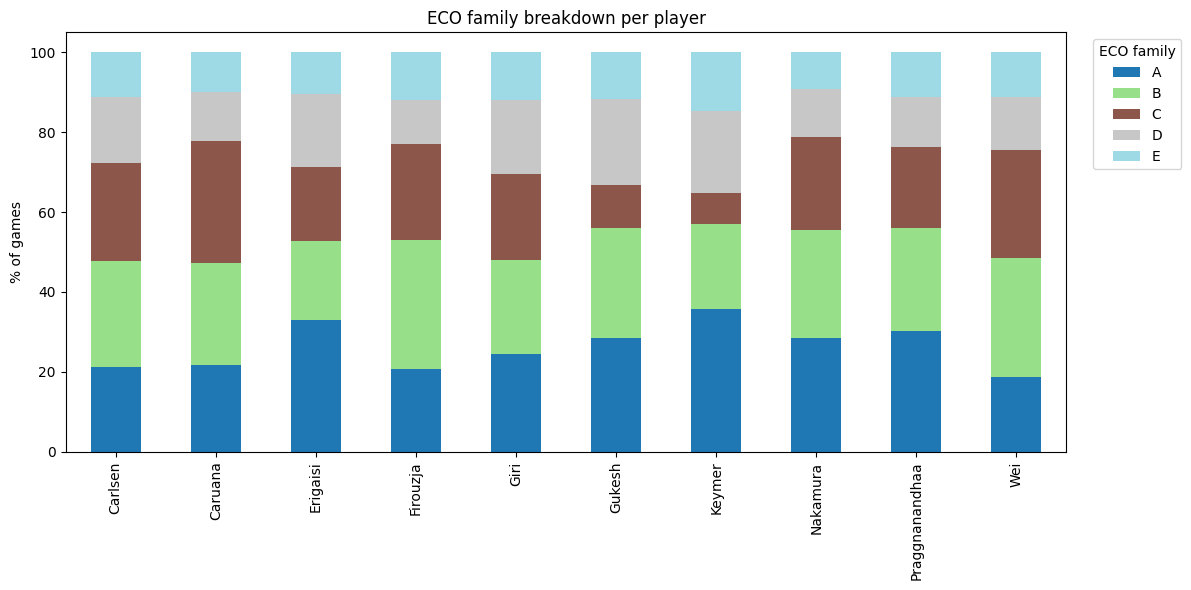

In [30]:
fig, ax = plt.subplots(figsize=(12,6))
family_df.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("% of games")
ax.set_title("ECO family breakdown per player")
ax.legend(title="ECO family", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

notes to self:
- pgn-extract.exe in /tools is a third party tool (not mine), used it earlier to clean up some of the raw pgn files before this notebook
- detection isn't 100%, somewhere around 70-90% depending on the player, probably because some games are too short or don't have a clean ECO match
- could probably add win rate per opening next, or split by year to see if openings changed over time